# Customer Behavior EDA

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

USE_SAMPLE = True
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from instacart_quality import load_eda_base

tables = load_eda_base(use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)
orders = tables["orders"]
order_products = tables["order_products_prior"]

df = order_products.merge(orders, on="order_id", how="left")
df = df.sort_values(["user_id", "order_number", "add_to_cart_order"]).reset_index(drop=True)
df["cumulative_reorder_per_customer"] = df.groupby("user_id")["reordered"].cumsum()

df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_reorder_per_customer
0,2127348,42489,1,1,52,prior,26,5,13,18.0,1
1,2127348,43352,2,0,52,prior,26,5,13,18.0,1
2,2127348,40063,3,1,52,prior,26,5,13,18.0,2
3,2127348,8048,4,1,52,prior,26,5,13,18.0,3
4,2127348,46516,5,1,52,prior,26,5,13,18.0,4


## Analysis Questions
- Do customers who reorder have shorter days between orders?
- Do high-order-history customers reorder more?
- How strongly does cumulative reorder history separate behavior groups?

In [2]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)

display(customer_kpi.describe(include="all"))

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        avg_days_since_prior_order=("days_since_prior_order", "mean"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
summary_by_reordered

,user_id,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,934.000000,934.00000,934.000000,934.000000,878.000000,934.000000
mean,102646.137045,16.64561,10.017131,0.594517,10.412534,5.938972
std,58553.666110,17.36370,7.207811,0.333806,8.761110,5.734901
min,52.000000,1.00000,1.000000,0.000000,0.000000,0.000000
25%,51330.000000,4.00000,5.000000,0.333333,4.000000,2.000000
50%,102861.500000,10.00000,8.000000,0.625000,7.000000,4.000000
75%,153112.750000,23.00000,14.000000,0.894737,14.000000,8.000000
max,206074.000000,99.00000,44.000000,1.000000,30.000000,33.000000


,avg_days_since_prior_order,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,11.487361,6.0,2.0,3809
1,9.700559,16.0,5.0,5547


## Bivariate Comparison

This section was moved from the overview notebook and consolidated here for customer behavior interpretation.

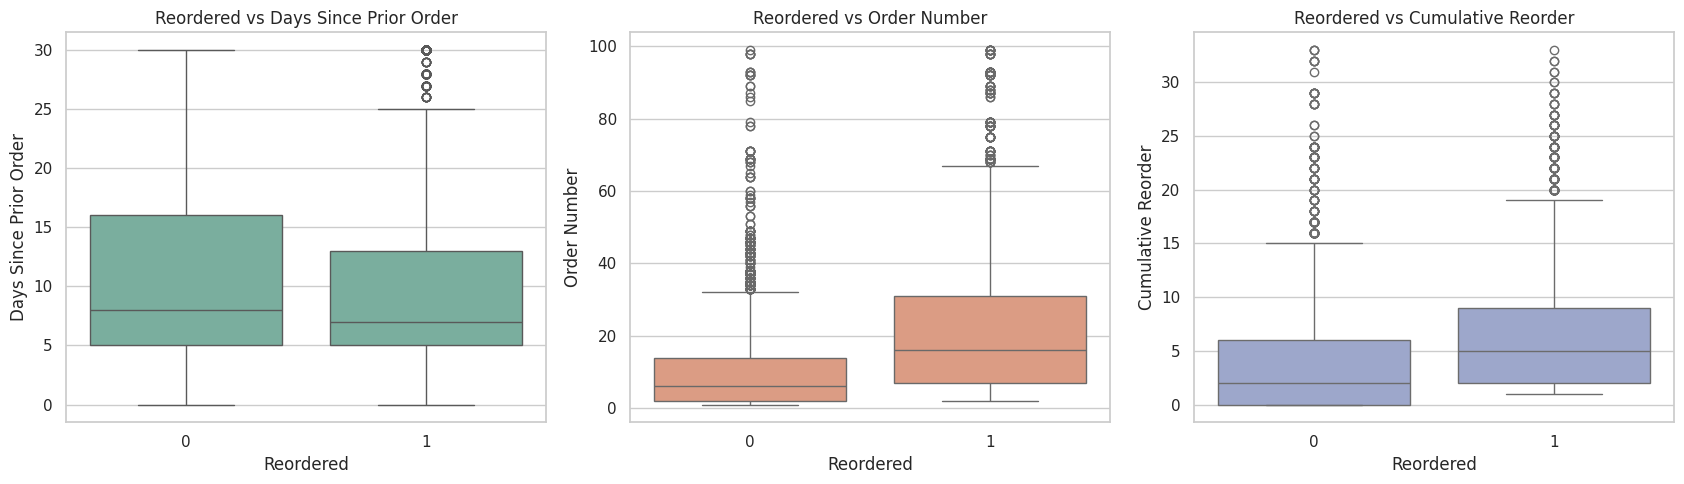

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [4]:
comparison_stats = {
    "days_since_prior_order_mean_diff": (
        df.loc[df["reordered"] == 1, "days_since_prior_order"].mean()
        - df.loc[df["reordered"] == 0, "days_since_prior_order"].mean()
    ),
    "order_number_median_diff": (
        df.loc[df["reordered"] == 1, "order_number"].median()
        - df.loc[df["reordered"] == 0, "order_number"].median()
    ),
    "cumulative_reorder_median_diff": (
        df.loc[df["reordered"] == 1, "cumulative_reorder_per_customer"].median()
        - df.loc[df["reordered"] == 0, "cumulative_reorder_per_customer"].median()
    ),
}

pd.Series(comparison_stats).to_frame("value")

,value
days_since_prior_order_mean_diff,-1.786802
order_number_median_diff,10.000000
cumulative_reorder_median_diff,3.000000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.